### Titanic Passengers Survival Data Analysis

In [ ]:
# Import Libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
# Load Dataset

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("train.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [ ]:
# Summary statistics for numerical columns
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [ ]:
# Summary statistics for categorical columns

print(df.describe(include=["O"]))

                       Name   Sex  Ticket Cabin Embarked
count                   891   891     891   204      889
unique                  891     2     681   147        3
top     Dooley, Mr. Patrick  male  347082    G6        S
freq                      1   577       7     4      644


In [ ]:
print("\nValue Counts: Pclass")
print(df["Pclass"].value_counts())

print("\nValue Counts: Sex")
print(df["Sex"].value_counts())

print("\nValue Counts: Embarked")
print(df["Embarked"].value_counts())


Value Counts: Pclass
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Value Counts: Sex
Sex
male      577
female    314
Name: count, dtype: int64

Value Counts: Embarked
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


/tmp/ipykernel_840/3472111224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='Set2')


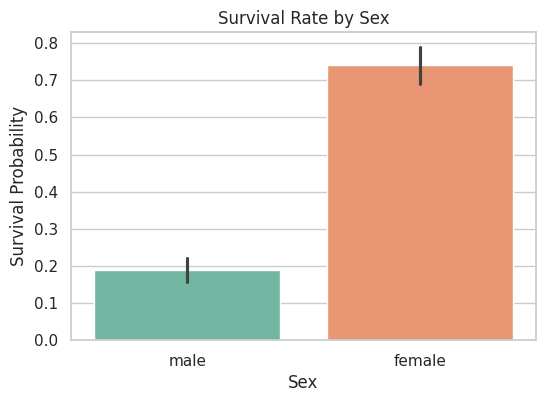

In [ ]:
# Survival Rate by Sex

plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=df, palette='Set2')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Probability')
plt.show()

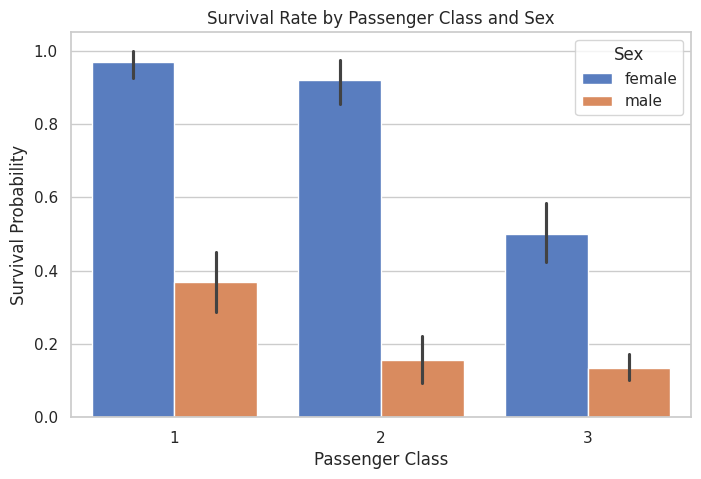

In [ ]:
# Survival Rate by Pclass and Sex
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, palette='muted')
plt.title('Survival Rate by Passenger Class and Sex')
plt.ylabel('Survival Probability')
plt.xlabel('Passenger Class')
plt.legend(title='Sex')
plt.show()

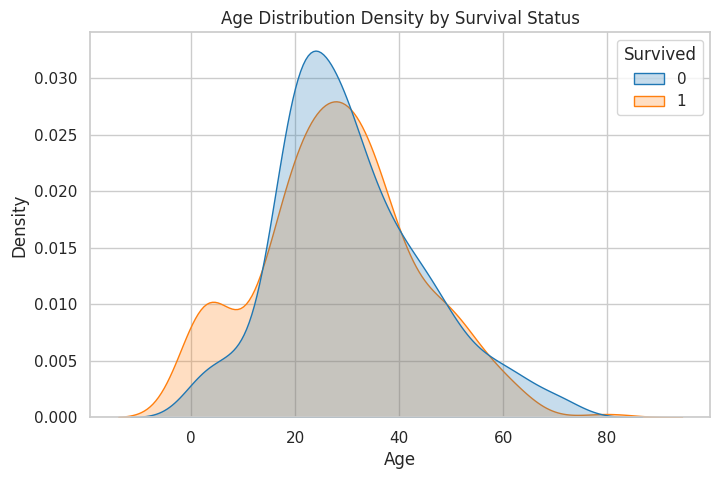

In [ ]:
# Age Distribution by Survival Status
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df, x='Age', hue='Survived', common_norm=False, fill=True, palette='tab10'
)
plt.title('Age Distribution Density by Survival Status')
plt.xlabel('Age')
plt.show()

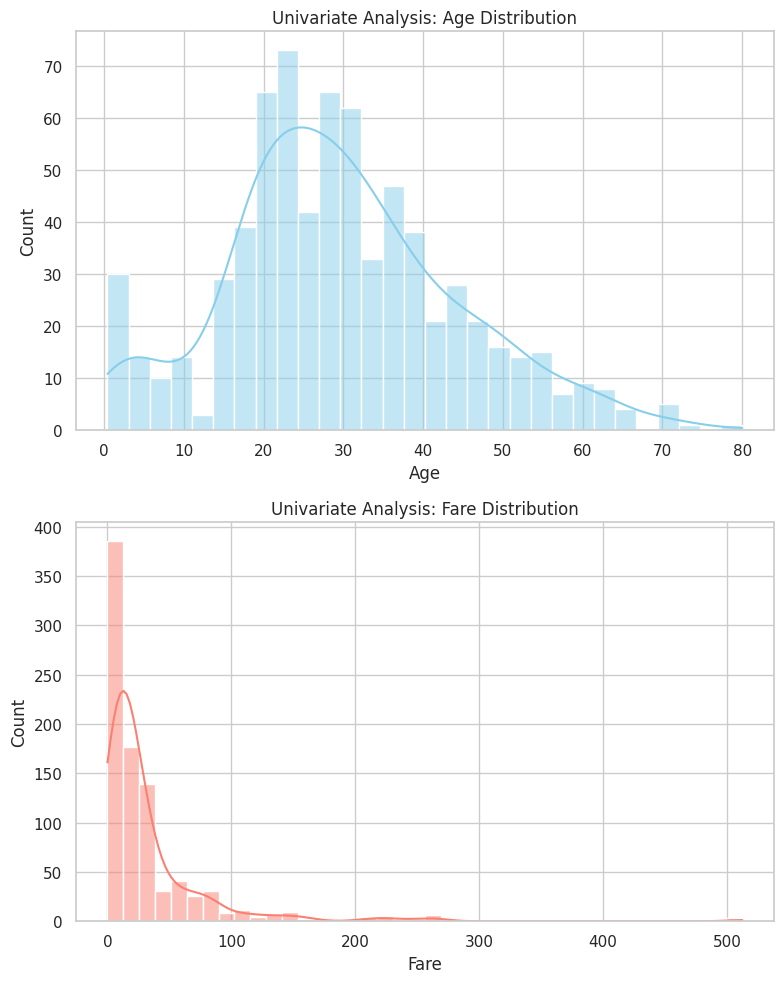

In [ ]:
# Histograms for Age and Fare distributions

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

sns.histplot(
    df["Age"].dropna(), kde=True, ax=axes[0], color="skyblue", bins=30
)
axes[0].set_title("Univariate Analysis: Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

sns.histplot(df["Fare"], kde=True, ax=axes[1], color="salmon", bins=40)
axes[1].set_title("Univariate Analysis: Fare Distribution")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

Age Distribution: Passenger ages are roughly bell-shaped and right-skewed, centered around a mean of 29.70 years and a median of 28.00 years, with a notable cluster of infants and young children.



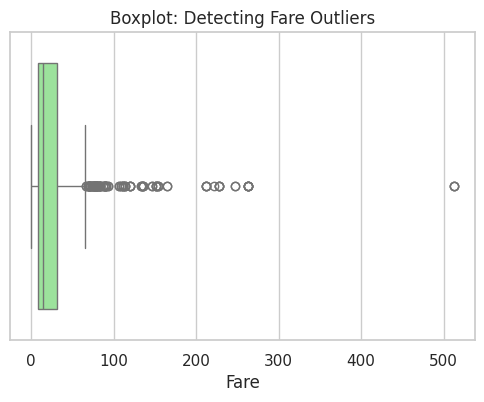

In [ ]:
# Boxplot

plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Fare"], color="lightgreen")
plt.title("Boxplot: Detecting Fare Outliers")
plt.xlabel("Fare")
plt.show()

Fare Distribution: Ticket prices are severely right-skewed. While the median fare was $14.45, the mean fare was $32.20, driven by extreme high-value outliers paying up to $512.33.

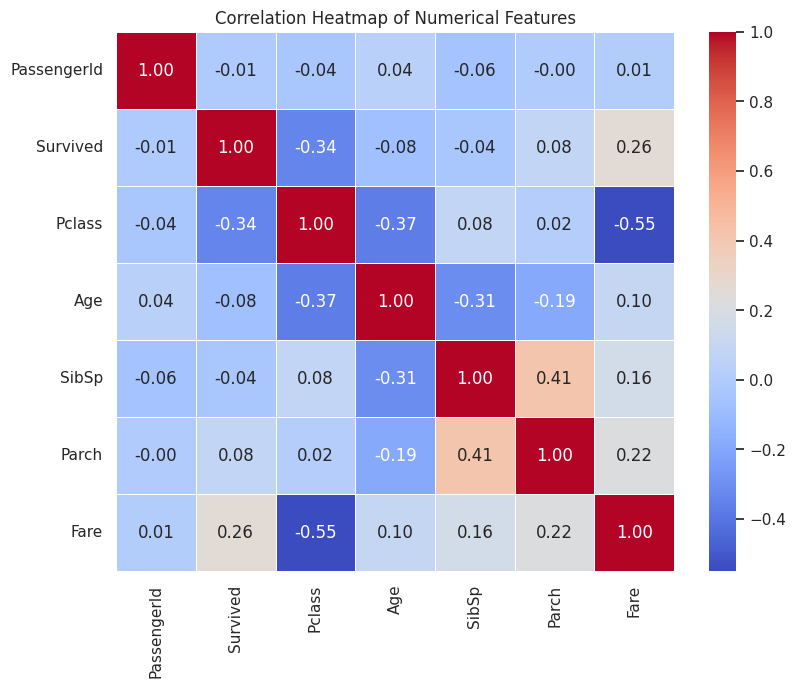

In [ ]:
# Correlation Heatmap (Numerical Relationships)
plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

The correlation heatmap revealed that Pclass and Fare had a strong negative correlation, Pclass and Survived had a negative relationship, and Fare and Survived had a positive relationship

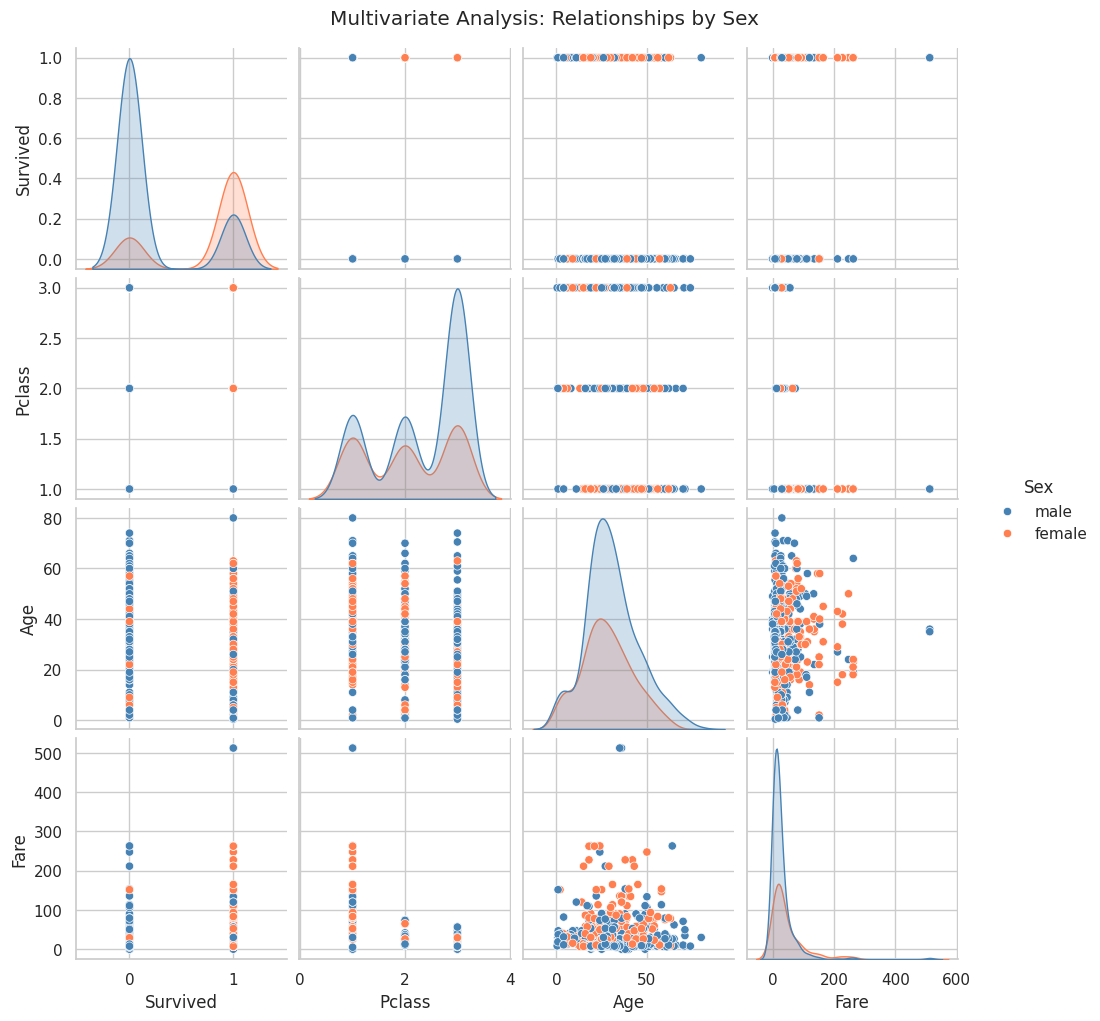

In [ ]:
# Pairplot with Hue for Multivariate Relationships
subset_df = df[["Survived", "Pclass", "Age", "Fare", "Sex"]].dropna()
pair_plot = sns.pairplot(
    subset_df, hue="Sex", palette={"male": "steelblue", "female": "coral"}
)
pair_plot.fig.suptitle(
    "Multivariate Analysis: Relationships by Sex", y=1.02
)
plt.show()

The multivariate pairplot showed clear separation by sex across most variables, with females surviving at much higher rates regardless of class or fare